# Sentiment analysis of the ParlaMint-SI dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../Datasets/Sentiment_Analysis/ParlaMint-SI.tsv', delimiter='\t', encoding='utf-8')
df.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,I'm starting with the 99th Extraordinary Meeti...,3.223034,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",I am informed that today's meeting cannot be a...,1.778516,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,I say hello to everyone who's here!,4.814360,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,We're moving on to 10.,3.219104,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


In [2]:
utt = df.drop_duplicates(subset=['ID']).reset_index(drop=True)
utt.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovane kolegice in kolegi, gospe in gospodje!","Dear colleagues, ladies and gentlemen!",3.846659,3.88,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,NP,Poslanska skupina nepovezanih poslancev,-,-,ZorčičIgor,"Zorčič, Igor",M,1978
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala lepa, predsedujoči.","Thank you very much, Chairman.",4.019485,3.19,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMP,notMinister,-,-,-,-,SlavinecMitja,"Slavinec, Mitja",M,1964
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


## Descriptive statistics

Checking distributions within the new ParlaMint-SI corpus and the characteristics of the political parties within

Corpus: 
- Total no. of speeches
- % of procedural speeches within the corpus (remove from the analysis)
- label distribution
- sentiment distribution overall (count, %)
- sentiment distribution across terms (count, %)
- sentiment distribution across political orientation (count, %)
- sentiment distribution across political status (coalition/opposition, (count, %))


In [50]:
utt_filter = utt[utt['Speaker_role'] == 'Regular'].reset_index()
utt_procedural = utt[utt['Speaker_role'] != 'Regular']


utt_labels = utt_filter['labels'].value_counts()
utt_sentiment = utt_filter['sentiment'].value_counts()

percent_procedural = (len(utt_procedural) / len(utt)) * 100
percent_lables = (utt_labels / len(utt_filter)) * 100
percent_sent = (utt_sentiment / len(utt_filter)) * 100

print("Total no. of speeches: ", len(utt_filter))
print("Total no. of procedural speeches: ", len(utt_procedural), "%: ", percent_procedural)
print("Earliest speech: ", utt['Date'].min())
print("Last speech: ", utt['Date'].max())
print("Distribution of the labels: ", percent_lables)
print("Distribution of the sentiment: ", percent_sent)

Total no. of speeches:  153763
Total no. of procedural speeches:  157584 %:  50.613624027210804
Earliest speech:  2000-10-27
Last speech:  2022-04-06
Distribution of the labels:  labels
Negative            42.146030
Mixed Negative      17.854750
Neutral Negative    14.145796
Neutral Positive    13.048002
Mixed Positive       9.593986
Positive             3.211436
Name: count, dtype: float64
Distribution of the sentiment:  sentiment
Negative    60.000780
Neutral     27.193798
Positive    12.805421
Name: count, dtype: float64


In [5]:
parties = utt_filter['Speaker_party'].value_counts()
orientations = utt_filter['Party_orientation'].value_counts()
status = utt_filter['Party_status'].value_counts()

percent_parties = (parties / len(utt_filter)) * 100
percent_orientations = (orientations / len(utt_filter)) * 100
percent_staus = (status / len(utt_filter)) * 100

print("% of speeches per political party:", percent_parties)
print("% of speeches for coalition/opposition: ", percent_staus)

% of speeches per political party: Speaker_party
SDS          22.746044
-            12.466588
SD           10.836807
LDS           9.169956
NSi           8.687396
SNS           5.139078
SLS           4.690985
DeSUS         4.417187
SMC           3.906011
Levica        3.122988
ZLSD          2.340615
PS            2.073971
LMŠ           1.827488
Zares         1.814481
ZL            1.582956
SAB           1.271437
NP            1.097793
DL            0.684820
NeP           0.534589
SLS+SKD       0.526134
SMS           0.458498
Lipa          0.256889
ZaAB          0.212015
Konkretno     0.074790
DLGV          0.060483
Name: count, dtype: float64
% of speeches for coalition/opposition:  Party_status
Opposition    44.975709
Coalition     36.848917
-             18.175374
Name: count, dtype: float64


In [6]:
print("% of speeches per political orientation:", percent_orientations)

% of speeches per political orientation: Party_orientation
Right                     22.806527
Centre to centre-left     21.394614
Centre-left               16.933853
-                         14.355859
Centre-right              13.904515
Right to far-right         5.139078
Left                       4.705944
Centre to centre-right     0.684820
Centre                     0.074790
Name: count, dtype: float64


In [7]:
orientation_count = utt_filter['Party_orientation'].value_counts()
orientation_check = utt_filter[['Party_orientation', 'Speaker_party']]
orientation_check = orientation_check.groupby('Party_orientation')['Speaker_party'].value_counts()

print(orientation_count)
print(orientation_check)


Party_orientation
Right                     35068
Centre to centre-left     32897
Centre-left               26038
-                         22074
Centre-right              21380
Right to far-right         7902
Left                       7236
Centre to centre-right     1053
Centre                      115
Name: count, dtype: int64
Party_orientation       Speaker_party
-                       -                19169
                        NP                1688
                        NeP                822
                        Lipa               395
Centre                  Konkretno          115
Centre to centre-left   LDS              14100
                        DeSUS             6792
                        SMC               6006
                        PS                3189
                        LMŠ               2810
Centre to centre-right  DL                1053
Centre-left             SD               16663
                        ZLSD              3599
                   

## Checking label distribution (without procedural speech)

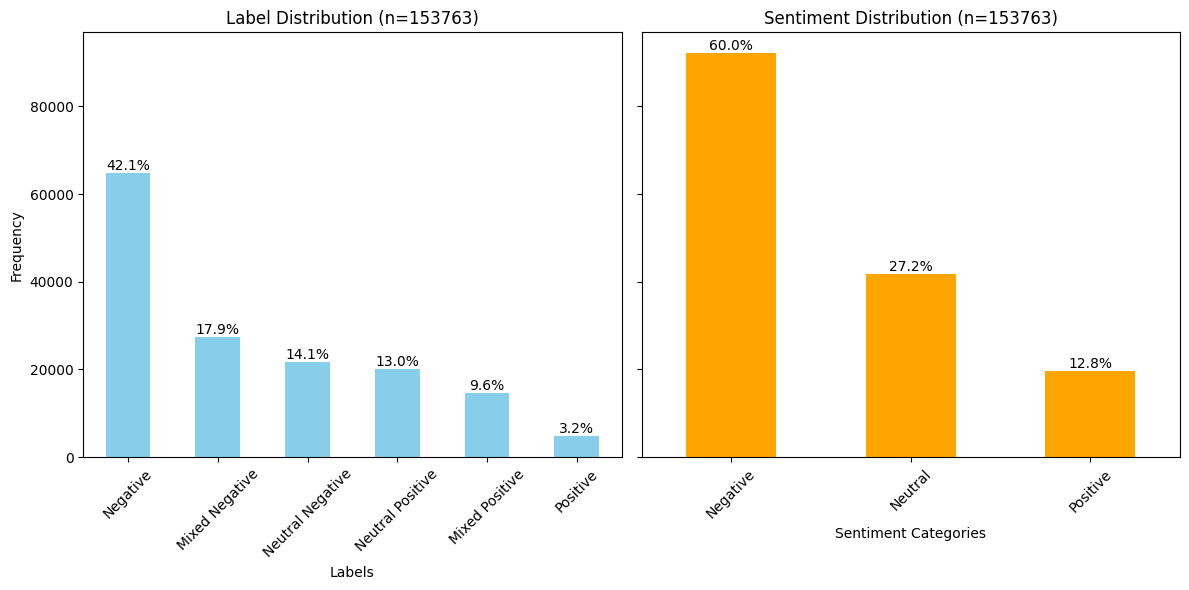

In [8]:
def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
utt_labels.plot(kind='bar', ax=axes[0], color = 'skyblue')
axes[0].set_title('Label Distribution (n=153763)')
axes[0].set_xlabel('Labels')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], utt_labels)

utt_sentiment.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Sentiment Distribution (n=153763)')
axes[1].set_xlabel('Sentiment Categories')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], utt_sentiment)

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_distribution.png', dpi=300)
plt.show()

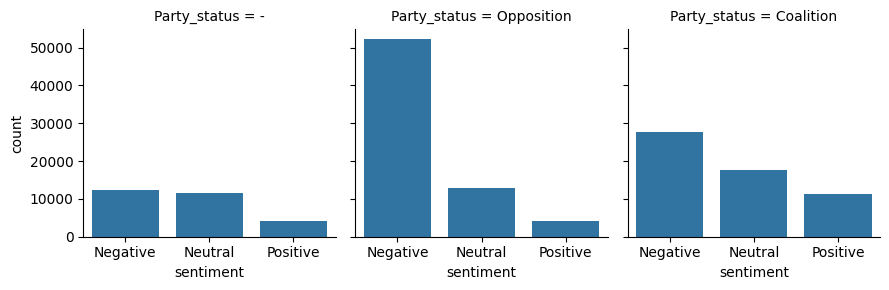

In [9]:
g = sns.FacetGrid(utt_filter, col="Party_status", margin_titles=True)
g.map(sns.countplot, "sentiment", order=["Negative", "Neutral", "Positive"])
#plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Party_status.png', dpi=300)
plt.show()

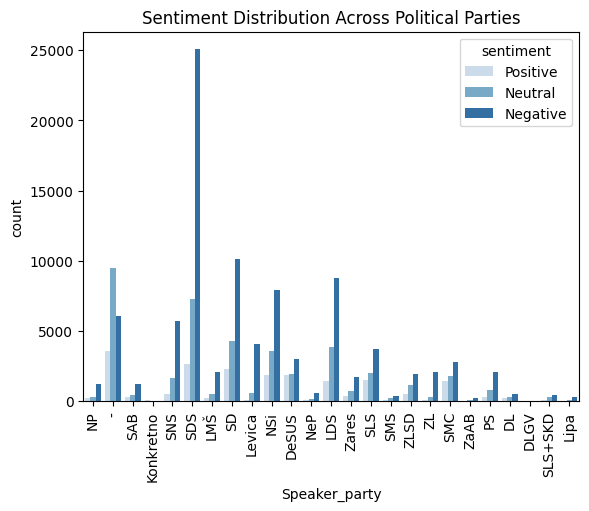

In [10]:
sns.countplot(data=utt_filter, x='Speaker_party', hue='sentiment', order=utt_filter['Speaker_party'].unique(), palette='Blues')
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Parties')
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Political_parties.png', dpi=300)

plt.show()

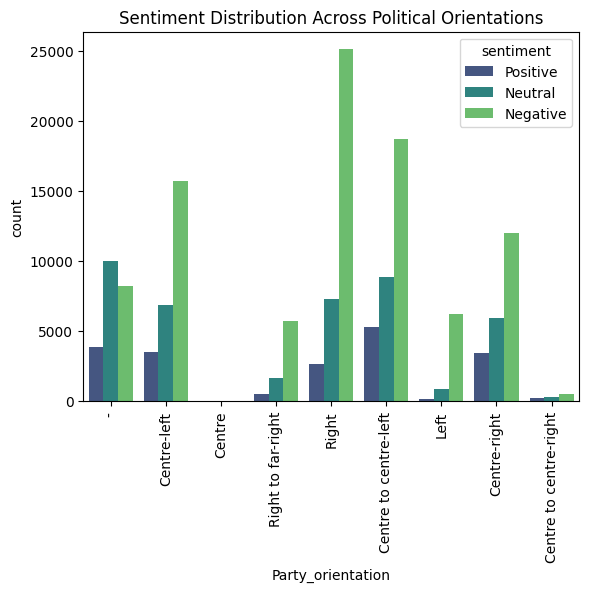

In [11]:
sns.countplot(data=utt_filter, x='Party_orientation', hue='sentiment', order=utt_filter['Party_orientation'].unique(), palette='viridis')
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Orientations')
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Orientation.png', dpi=300)

plt.show()

## Percentage of Negative speeches per individual party/political orientation/
Different visualizations & checking percentage of negative speeches to get a better interpretations of the data

In [12]:
pivot_parties = pd.crosstab(utt_filter['Speaker_party'], utt_filter['sentiment'])
#sns.heatmap(pivot_parties, annot=True, cmap='flare', fmt='d', cbar=False)
#plt.title('Sentiment by Political party')
#plt.show()

In [13]:
pivot_parties['Total'] = pivot_parties.sum(axis=1)
pivot_parties['% Negative'] = (pivot_parties.get('Negative', 0) / pivot_parties['Total']) * 100
pivot_parties['% Negative'] = pivot_parties['% Negative'].round(2)

pivot_parties

sentiment,Negative,Neutral,Positive,Total,% Negative
Speaker_party,,,,,
-,6096,9501,3572,19169,31.80
DL,537,297,219,1053,51.00
DLGV,34,20,39,93,36.56
DeSUS,2985,1929,1878,6792,43.95
Konkretno,28,33,54,115,24.35
LDS,8790,3851,1459,14100,62.34
LMŠ,2055,519,236,2810,73.13
Levica,4099,592,111,4802,85.36
Lipa,304,75,16,395,76.96


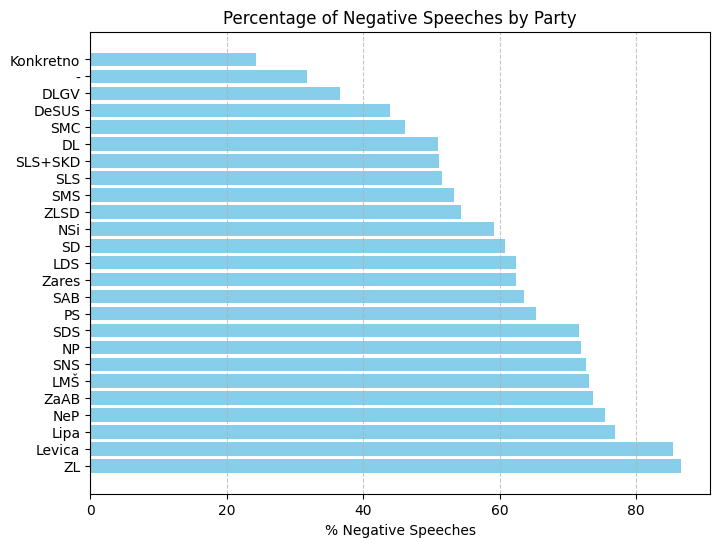

In [14]:
pivot_parties_sorted = pivot_parties.sort_values('% Negative', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(pivot_parties_sorted.index, pivot_parties_sorted['% Negative'], color='skyblue')
plt.xlabel('% Negative Speeches')
plt.title('Percentage of Negative Speeches by Party')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('../../Figures/Sentiment_Analysis/Negative_Speech_by_Party.png', dpi=300)

plt.show()

## Checking sentiment across terms

In [15]:
mandates = utt_filter[['ID', 'Term', 'Date', 'utt_annotations', 'labels', 'sentiment', 'Speaker_party', 'Party_status', 'Party_orientation']]
mandates

,ID,Term,Date,utt_annotations,labels,sentiment,Speaker_party,Party_status,Party_orientation
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,8. mandat,2022-04-06,3.88,Mixed Positive,Positive,NP,-,-
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,8. mandat,2022-04-06,3.19,Neutral Positive,Neutral,-,-,-
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,8. mandat,2022-04-06,4.38,Mixed Positive,Positive,SAB,Opposition,Centre-left
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,8. mandat,2022-04-06,3.94,Mixed Positive,Positive,Konkretno,Coalition,Centre
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,8. mandat,2022-04-06,4.92,Positive,Positive,SNS,Opposition,Right to far-right
...,...,...,...,...,...,...,...,...,...
153758,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u237,4. mandat,2005-01-24,1.88,Neutral Negative,Neutral,NSi,Coalition,Centre-right
153759,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u239,4. mandat,2005-01-24,2.52,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left
153760,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u241,4. mandat,2005-01-24,1.49,Mixed Negative,Negative,LDS,Opposition,Centre to centre-left
153761,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,4. mandat,2005-01-24,2.75,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left


In [16]:
import numpy as np
#Droping the utterances, where the speakers are not affiliated with political parties
mandates.replace('-', np.nan, inplace=True)
print(len(mandates))

terms = mandates.copy()
terms['Term'] = mandates['Term'].replace({
    '3. mandat': 'Term 3',
    '4. mandat': 'Term 4',
    '5. mandat': 'Term 5',
    '6. mandat': 'Term 6',
    '7. mandat': 'Term 7',
    '8. mandat': 'Term 8'
})
terms['utt_annotations'] = pd.to_numeric(terms['utt_annotations'])
trends = terms.groupby(['Speaker_party', 'Term']).agg({'utt_annotations':'mean'}).reset_index()
trends['Term'] = pd.Categorical(trends['Term'], ordered=True)

trends


153763


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_70675/3666362565.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mandates.replace('-', np.nan, inplace=True)


,Speaker_party,Term,utt_annotations
0,DL,Term 6,1.827236
1,DLGV,Term 6,2.553871
2,DeSUS,Term 3,2.168994
3,DeSUS,Term 4,1.860725
4,DeSUS,Term 5,2.474093
...,...,...,...
60,ZLSD,Term 4,1.063720
61,ZaAB,Term 6,1.994286
62,ZaAB,Term 7,0.892525
63,Zares,Term 4,0.711831


In [17]:
terms['Year'] = terms['Date'].str.split('-').str[0]
term6 = terms[terms['Term'] == 'Term 6']
term5 = terms[terms['Term'] == 'Term 5']
DeSUS = terms[terms['Speaker_party'] == 'DeSUS']

print("Earliest Term5 speech: ", term5['Date'].min())
print("Last Term5 speech: ", term5['Date'].max())

print("Earliest Term6 speech: ", term6['Date'].min())
print("Last Term6 speech: ", term6['Date'].max())

Earliest Term5 speech:  2008-10-15
Last Term5 speech:  2012-06-16
Earliest Term6 speech:  2011-12-21
Last Term6 speech:  2014-07-04


In [18]:
mismatch = term5[term5['Year'] == '2012']
update = mismatch.index
terms.loc[update, 'Term'] = 'Term 6'

terms_check = terms[terms['Term'] == 'Term 5']
print("Earliest Term5 speech: ", terms_check['Date'].min())
print("Last Term5 speech: ", terms_check['Date'].max())

Earliest Term5 speech:  2008-10-15
Last Term5 speech:  2011-12-08


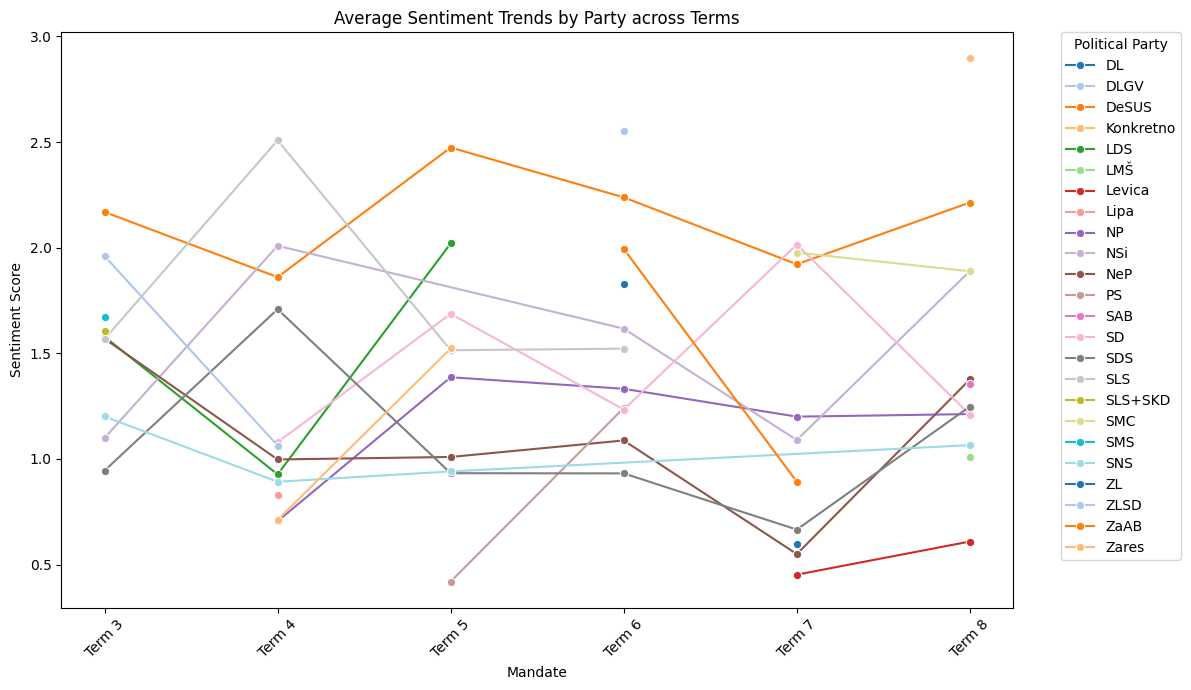

In [19]:
plt.figure(figsize=(12, 7))

sns.lineplot(data=trends, x='Term', y='utt_annotations', hue='Speaker_party', marker='o', linewidth=1.5, palette='tab20')

plt.title('Average Sentiment Trends by Party across Terms')
plt.xlabel('Mandate')
plt.ylabel('Sentiment Score')
plt.legend(title='Political Party', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xticks(rotation=45)
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_Trends.png', dpi=300)

plt.tight_layout()



## Checking sentiment trends within each term

In [51]:
government = pd.DataFrame({
    'Government': ['Gov5', 'Gov6', 'Gov7', 'Gov8', 'Gov9', 'Gov10', 'Gov11', 'Gov12', 'Gov13', 'Gov14'],
    'Start_Date': ['2000-06-07', '2000-12-01', '2002-12-20', '2004-12-04', '2008-11-22', '2012-02-11', '2013-03-21', '2014-09-19', '2018-09-14', '2020-03-14'],
    'End_Date': ['2000-11-30', '2002-12-19', '2004-12-03', '2008-11-21', '2012-02-10', '2013-03-20', '2014-09-18', '2018-09-13', '2020-03-13', '2022-06-01']
})

government['Start_Date'] = pd.to_datetime(government['Start_Date'])
government['End_Date'] = pd.to_datetime(government['End_Date'])
government
terms['Date'] = pd.to_datetime(terms['Date'])

def map_government(date):
    for _, row in government.iterrows():
        if row['Start_Date'] <= date <= row['End_Date']:
            return row['Government']
    return None

# Apply the function to add a new column
terms['Government'] = terms['Date'].apply(map_government)

terms

,ID,Term,Date,utt_annotations,labels,sentiment,Speaker_party,Party_status,Party_orientation,Year,Government
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,Term 8,2022-04-06,3.88,Mixed Positive,Positive,NP,NaN,NaN,2022,Gov14
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,Term 8,2022-04-06,3.19,Neutral Positive,Neutral,NaN,NaN,NaN,2022,Gov14
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,Term 8,2022-04-06,4.38,Mixed Positive,Positive,SAB,Opposition,Centre-left,2022,Gov14
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,Term 8,2022-04-06,3.94,Mixed Positive,Positive,Konkretno,Coalition,Centre,2022,Gov14
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,Term 8,2022-04-06,4.92,Positive,Positive,SNS,Opposition,Right to far-right,2022,Gov14
...,...,...,...,...,...,...,...,...,...,...,...
153758,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u237,Term 4,2005-01-24,1.88,Neutral Negative,Neutral,NSi,Coalition,Centre-right,2005,Gov8
153759,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u239,Term 4,2005-01-24,2.52,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left,2005,Gov8
153760,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u241,Term 4,2005-01-24,1.49,Mixed Negative,Negative,LDS,Opposition,Centre to centre-left,2005,Gov8
153761,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,Term 4,2005-01-24,2.75,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left,2005,Gov8


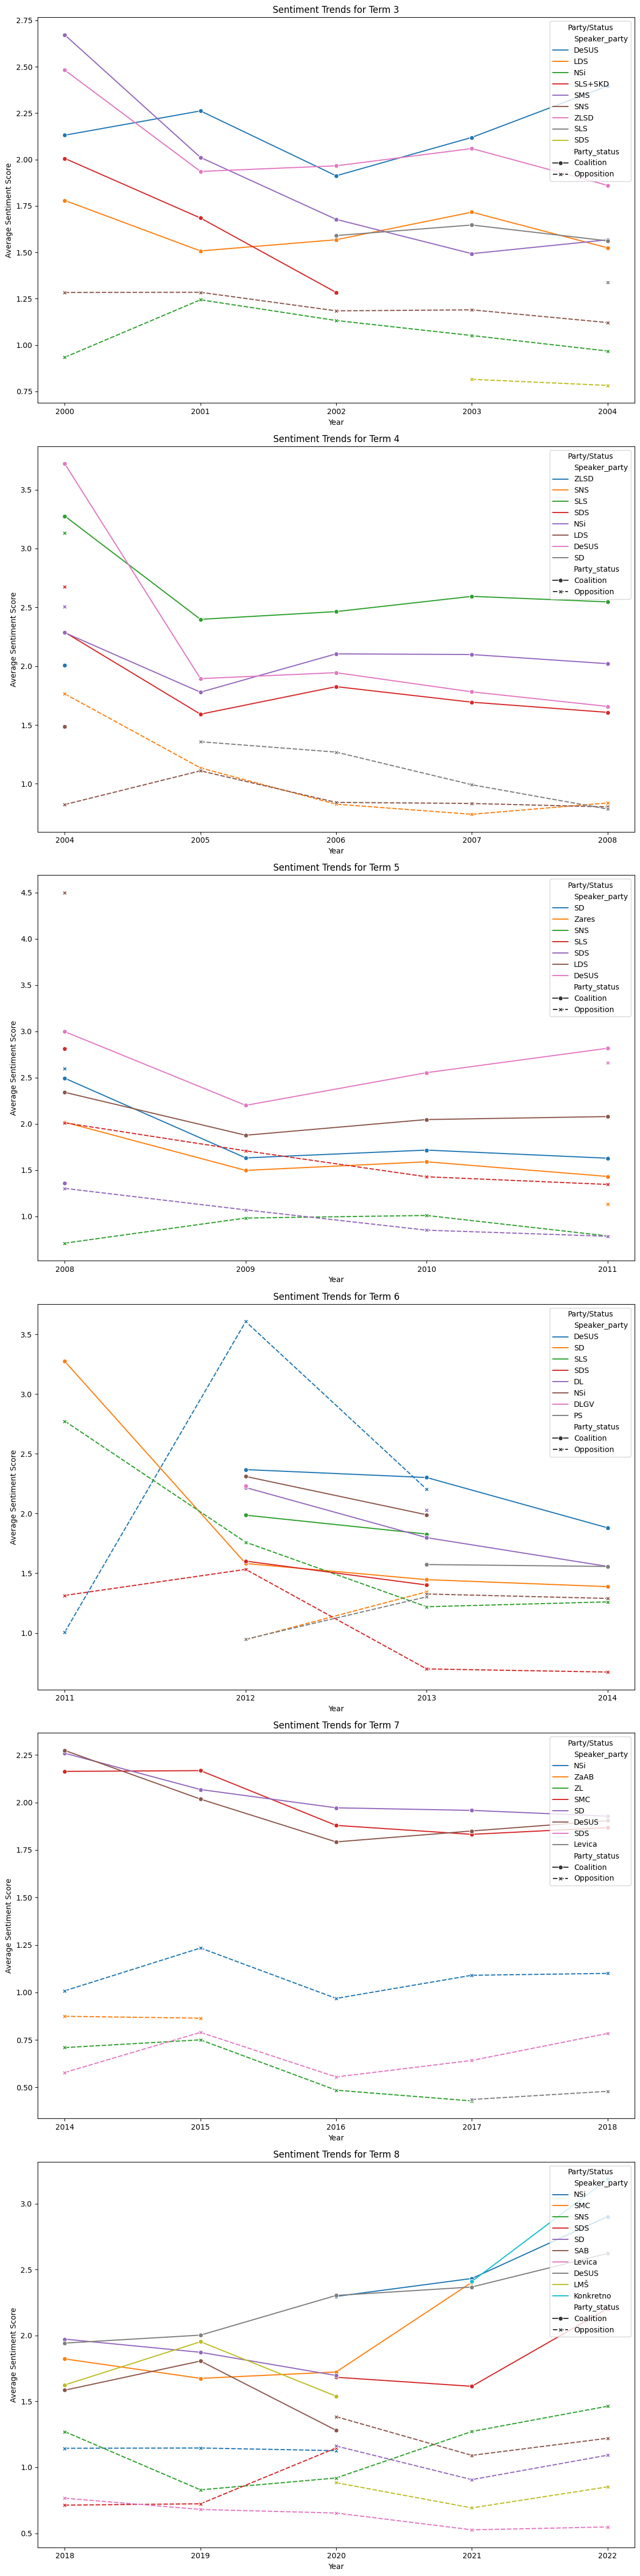

In [53]:
term_sent = terms.groupby(['Term', 'Year', 'Speaker_party', 'Party_status']).agg({'utt_annotations':'mean'}).reset_index()
term_sent['Party_status'] = term_sent['Party_status'].astype('category')
term_sent = term_sent.sort_values(by='Year', ascending=True)

## Giving each individual political party a colour to be tracked throughout the subplots (not distinctive enough)
#unique_parties = term_sent['Speaker_party'].unique()
#party_palette = sns.color_palette("Set2", n_colors=len(unique_parties))
#party_color_mapping = {party: party_palette[i] for i, party in enumerate(unique_parties)}


n_terms = term_sent['Term'].unique()


fig, axes = plt.subplots(len(n_terms), 1, figsize=(12, 8 * len(n_terms)))

for i, term in enumerate(n_terms):
    ax = axes[i] if len(n_terms) > 1 else axes
    term_data = term_sent[term_sent['Term'] == term]

    sns.lineplot(data=term_data, x='Year', y='utt_annotations', hue='Speaker_party', style='Party_status' , ax=ax, markers=True)
    ax.set_title(f"Sentiment Trends for {term}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Sentiment Score')
    ax.legend(title='Party/Status', loc='upper right')

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_for_Terms.png', dpi=300)

plt.show()



Interpretation of the trends witih individual mandate:

-Term 6: The overlap between the coalition and opposition values for certain political parties is due to the fact that there is a change in the government - Term 6 observes multiple government structures in its duration, namely: 
- 9. Vlada Republike Slovenije (21. 11. 2008 - 10. 2. 2012)
predsednik vlade Borut Pahor
- 10. Vlada Republike Slovenije (10. 2. 2012 - 20. 3. 2013)
predsednik vlade Janez Janša
- 11. Vlada Republike Slovenije (20. 3. 2013 - 18. 9. 2014)
predsednica vlade mag. Alenka Bratušek



In [48]:
###Generating individual plots for a paper/chapter
for term in n_terms:
    term_data = term_sent[term_sent['Term'] == term]
    
    plt.figure(figsize=(12, 8))
    
    sns.lineplot(data=term_data, x='Year', y='utt_annotations', hue='Speaker_party',
                 style='Party_status', markers=True)
    
    plt.title(f"Sentiment Trends for {term}")
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment Score')
    plt.legend(title='Party/Status', loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f'../../Figures/Sentiment_Analysis/Terms/Sentiment_{term}.png', dpi=300)
    
    plt.close()

In [49]:
term_sent.to_csv('../../Tables/Terms.csv', encoding='utf-8', index=False)